In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import joblib
import os

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, df[col].median())

In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [5]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [7]:
smote = SMOTE(random_state=42)
Xtrain_sm, ytrain_sm = smote.fit_resample(Xtrain, ytrain)

In [8]:
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(Xtrain_sm, ytrain_sm)

RandomForestClassifier(n_estimators=150, random_state=42)

In [9]:
y_pred = model.predict(Xtest)
acc = accuracy_score(ytest, y_pred)

In [10]:
print("🎯 Accuracy:", acc)
print("📊 Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
print("📋 Classification Report:\n", classification_report(ytest, y_pred))

🎯 Accuracy: 0.7727272727272727
📊 Confusion Matrix:
 [[77 22]
 [13 42]]
📋 Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.78      0.81        99
           1       0.66      0.76      0.71        55

    accuracy                           0.77       154
   macro avg       0.76      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154



In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 54.1 KB


In [15]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [16]:
df['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

C:\Users\amudh\AppData\Local\Temp\ipykernel_31464\2863690015.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


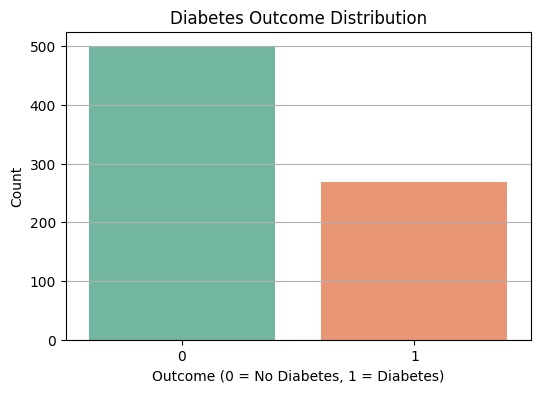

In [17]:
# Visualize Outcome distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


In [18]:

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros")


Glucose: 0 zeros
BloodPressure: 0 zeros
SkinThickness: 0 zeros
Insulin: 0 zeros
BMI: 0 zeros


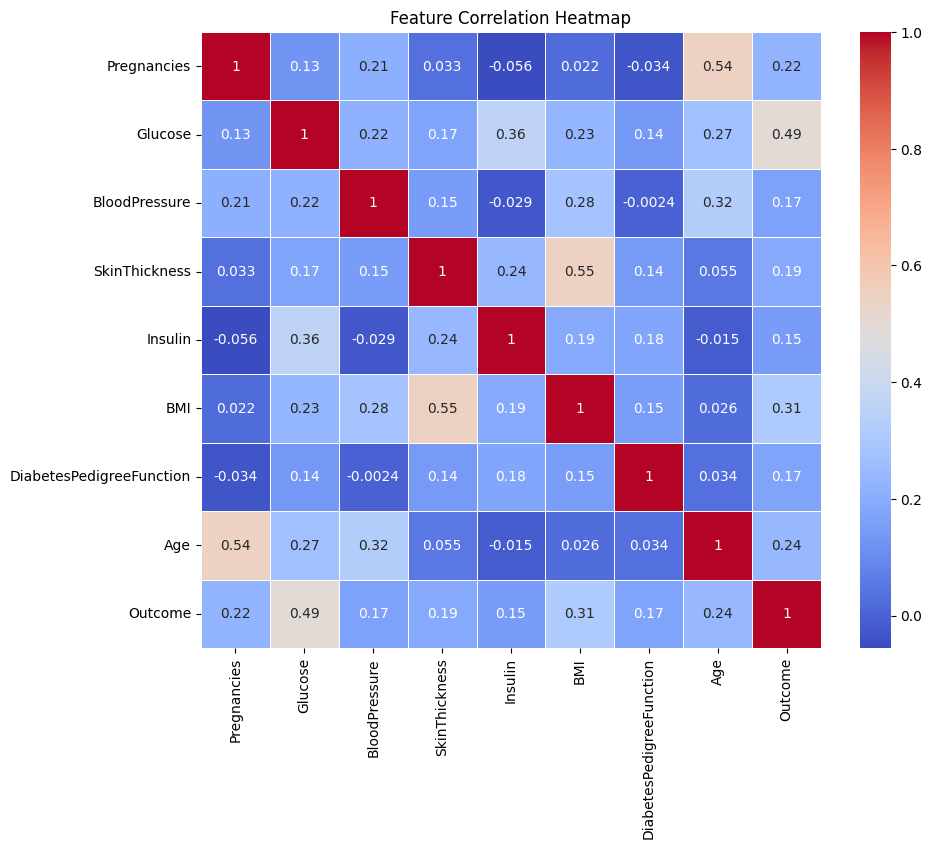

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [20]:
print("🎯 Accuracy:", acc)
print("📊 Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
print("📋 Classification Report:\n", classification_report(ytest, y_pred))

🎯 Accuracy: 0.7727272727272727
📊 Confusion Matrix:
 [[77 22]
 [13 42]]
📋 Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.78      0.81        99
           1       0.66      0.76      0.71        55

    accuracy                           0.77       154
   macro avg       0.76      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154

